# O Horizonte de Rindler

**Estudante:** Ricardo Albrecht

Neste notebook, vamos adicionar ao diagrama do cone de luz a linha de mundo hiperbólica de um observador com aceleração própria constante $a_0$, dada por $x^2 - t^2 = 1/a_0^2$. Vamos também analisar analitica e numericamente o encontro dessa trajetória com um fóton emitido em $t=0$ da posição $x_0$.


## 1. Modificando a Figura do Cone de Luz com a Hipérbole de Rindler

A trajetória de um observador uniformemente acelerado (Rindler) em unidades geometrizadas ($c=1$) satisfaz:
$$x^2 - t^2 = \frac{1}{a_0^2} \implies x(t) = \sqrt{\frac{1}{a_0^2} + t^2}$$

Vamos atualizar a função do cone de luz para desenhar essa hipérbole e sua assíntota $x = t$.

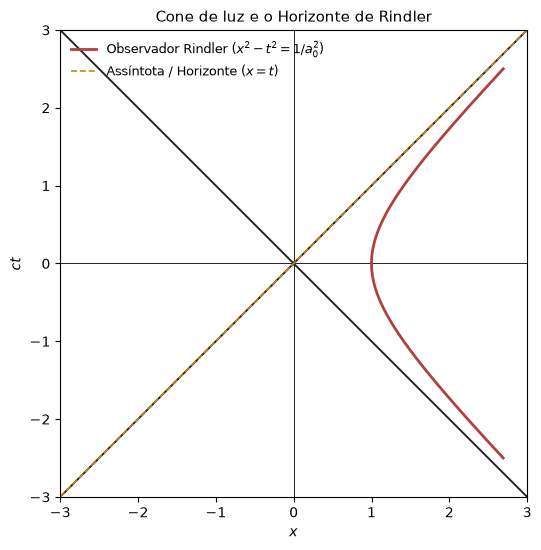

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

HALO = [pe.withStroke(linewidth=3.0, foreground="white")]

def fig_cone_luz_rindler():
    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.axhline(0, color="black", lw=0.6, zorder=1)
    ax.axvline(0, color="black", lw=0.6, zorder=1)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$ct$")

    x = np.linspace(-3, 3, 200)
    # Cone de luz
    ax.plot(x, np.abs(x), color="0.15", lw=1.4)
    ax.plot(x, -np.abs(x), color="0.15", lw=1.4)

    # Parâmetro de aceleração a0
    a0 = 1.0
    t_vals = np.linspace(-2.5, 2.5, 400)
    # Linha de mundo de Rindler: x = sqrt(1/a0^2 + t^2)
    x_rindler = np.sqrt((1.0 / a0**2) + t_vals**2)
    
    ax.plot(x_rindler, t_vals, color="#B0413E", lw=2.0, label=r"Observador Rindler ($x^2-t^2=1/a_0^2$)")
    
    # Assíntota x = t (ou ct = x)
    ax.plot(x, x, color="#C08A1E", lw=1.2, ls="--", label="Assíntota / Horizonte ($x=t$)")

    ax.set_title("Cone de luz e o Horizonte de Rindler", fontsize=11)
    ax.legend(fontsize=9, loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

fig_cone_luz_rindler()

## 2. Derivação e Verificação do Tempo de Encontro com o Fóton

Um fóton emitido em $t = 0$ na posição $x_0$ rumo a $+x$ tem a trajetória:
$$x(t) = x_0 + t$$

Para encontrar o instante $t$ em que o fóton alcança o observador de Rindler, igualamos as duas expressões para $x$:
$$x_0 + t = \sqrt{\frac{1}{a_0^2} + t^2}$$

Elevando ambos os lados ao quadrado (assumindo $x_0 + t > 0$):
$$(x_0 + t)^2 = \frac{1}{a_0^2} + t^2 \implies x_0^2 + 2x_0 t + t^2 = \frac{1}{a_0^2} + t^2$$

Cancelando $t^2$ dos dois lados:
$$x_0^2 + 2x_0 t = \frac{1}{a_0^2} \implies 2x_0 t = \frac{1}{a_0^2} - x_0^2$$

Isolando o tempo de encontro $t$:
$$t = \frac{1/a_0^2 - x_0^2}{2x_0}$$

## 3. Análise dos Casos para $x_0$

Vamos escrever uma função simples para calcular esse tempo de encontro dado $x_0$ e $a_0$, e testar os diferentes regimes físicos:

In [2]:
def tempo_encontro(x0, a0=1.0):
    if x0 <= 0:
        return np.nan # Nunca alcança ou está à esquerda/na origem
    return ((1.0 / a0**2) - x0**2) / (2.0 * x0)

# Testando diferentes posições iniciais x0 (com a0 = 1.0):
a0 = 1.0
x0_valores = [0.2, 0.5, 0.8, 1.0, 1.2, 0.0, -0.5]

print("Resultados do encontro do fóton com o observador acelerado:")
for x0 in x0_valores:
    t_enc = tempo_encontro(x0, a0)
    if np.isnan(t_enc) or t_enc < 0:
        status = "O fóton NUNCA alcança o observador (ou x0 <= 0)"
    else:
        status = f"Encontro ocorre em t = {t_enc:.3f}"
    print(f"  x0 = {x0:+.1f} -> {status}")

Resultados do encontro do fóton com o observador acelerado:
  x0 = +0.2 -> Encontro ocorre em t = 2.400
  x0 = +0.5 -> Encontro ocorre em t = 0.750
  x0 = +0.8 -> Encontro ocorre em t = 0.225
  x0 = +1.0 -> Encontro ocorre em t = 0.000
  x0 = +1.2 -> O fóton NUNCA alcança o observador (ou x0 <= 0)
  x0 = +0.0 -> O fóton NUNCA alcança o observador (ou x0 <= 0)
  x0 = -0.5 -> O fóton NUNCA alcança o observador (ou x0 <= 0)


## 4. Conclusão Física

1. **$0 < x_0 < 1/a_0$**: O tempo $t$ é positivo e o fóton consegue alcançar o observador acelerado.
2. **$x_0 \ge 1/a_0$**: O fóton já começa atrás ou muito perto da hipérbole em uma região onde o observador se afasta mais rápido do que a luz pode fechar a distância.
3. **$x_0 = 0$ (caso crítico)**: O fóton é emitido exatamente na origem e persegue o observador assintoticamente ($x = t$), mas **nunca o alcança**. A reta $x = t$ torna-se um **horizonte de eventos** para o observador acelerado.